In [1]:
from comparison.load_dataset import load_dataset
from comparison.yolo_detector import YOLODetector
from comparison.rf_detr_detector import RFDETRDetector
from comparison.deep_forest_detector import BirdDetector
from comparison.rt_detr_detector import RTDETRDetector
from comparison.metrics import evaluate_model
from comparison.visualizations import plot_pr_curves, plot_comparison_table, plot_all_confusion_matrices
from comparison.metrics import evaluate_model, count_ground_truth, count_predictions, attach_count_metrics

In [2]:
DATASET = dict(
    image_dir = "data/uk__test_stitch/images",
    label_dir = "data/uk__test_stitch/labels",
)
CONF = 0.2
IOU_NMS = 0.2
IOU_MATCH = 0.5

In [3]:
models = [
    lambda: BirdDetector(
        use_release=True,
        name="BirdDetector_release"
    ),
    lambda: BirdDetector(
        use_release=False,
        checkpoint_path="runs/deepforest_v2_neg/best.ckpt",
        name="BirdDetector_trained"
    ),
    lambda: YOLODetector("runs/yolo_cut_data_v2/weights/best.pt", name="YOLO"),
    lambda: YOLODetector("runs/yolo_cut_data_v2_uk_unlabeled/weights/best.pt", name="YOLO_more_data"),
    lambda: YOLODetector("runs/yolo_cut_data_v2_uk_unlabeled_aug/weights/best.pt", name="YOLO_augmentation"),

    lambda: RFDETRDetector("runs/rf_detr_v2/checkpoint_best_ema.pth", name="RFDETR"),
    lambda: RFDETRDetector("runs/rf_detr_v2_uk_unlabeled/checkpoint_best_ema.pth", name="RFDETR_more_data"),
    lambda: RFDETRDetector("runs/rf_detr_v2_uk_unlabeled_aug/checkpoint_best_ema.pth", name="RFDETR_augmentation"),

    lambda: RTDETRDetector("runs/rt_detr_v2/weights/best.pt", name="RTDETR"),
    lambda: RTDETRDetector("runs/rt_detr_v2_uk_unlabeled/weights/best.pt", name="RTDETR_more_data"),
    lambda: RTDETRDetector("runs/rt_detr_v2_uk_unlabeled_m/weights/best.pt", name="RTDETR_best_parameters"),
]

In [4]:
samples = load_dataset(**DATASET)
print(f"Loaded {len(samples)} samples")

Loaded 289 samples


In [5]:
true_gt = count_ground_truth(samples, iou_nms=IOU_NMS)
print(f"True GT count: {true_gt}")

True GT count: 1940


In [6]:
results = []
for create_model in models:
    m = create_model()
    print(f"Evaluating {m.name}...")

    r          = evaluate_model(m, samples, conf=CONF, iou_nms=IOU_NMS, iou_match=IOU_MATCH)
    true_pred  = count_predictions(m, samples, conf=CONF, iou_nms=IOU_NMS)
    r          = attach_count_metrics(r, true_gt, true_pred)

    print(f"  mAP@50={r.map50:.4f}  P={r.precision:.4f}  R={r.recall:.4f}  F1={r.f1:.4f}")
    print(f"  GT={true_gt}  Pred={true_pred}  Error={r.count_error:+d}  ({r.count_error_pct:+.1f}%)")
    print(f"  Speed: {r.time_per_image_ms:.1f}ms/tile  {r.fps:.1f} FPS  total={r.inference_time_s:.1f}s")

    results.append(r)
    del m

Reading config file: /home/skateryna/diploma_v3/penguin_env/lib/python3.13/site-packages/deepforest/data/deepforest_config.yml


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


No validation file provided. Turning off validation loop
Model from BirdDetector Repo release https://github.com/weecology/BirdDetector/releases/tag/1.1 was already downloaded. Loading model from file.
Loading pre-built model: https://github.com/weecology/BirdDetector/releases/tag/1.1
Setting default score threshold to 0.3
Evaluating BirdDetector_release...
  mAP@50=0.0719  P=0.2668  R=0.2417  F1=0.2536
  GT=1940  Pred=1871  Error=-69  (-3.6%)
  Speed: 526.8ms/tile  1.9 FPS  total=152.2s
Reading config file: /home/skateryna/diploma_v3/penguin_env/lib/python3.13/site-packages/deepforest/data/deepforest_config.yml


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


No validation file provided. Turning off validation loop
Evaluating BirdDetector_trained...
  mAP@50=0.6247  P=0.5058  R=0.7452  F1=0.6026
  GT=1940  Pred=3018  Error=+1078  (+55.6%)
  Speed: 68.3ms/tile  14.6 FPS  total=19.7s
Evaluating YOLO...
  mAP@50=0.7655  P=0.6573  R=0.8280  F1=0.7329
  GT=1940  Pred=2544  Error=+604  (+31.1%)
  Speed: 24.6ms/tile  40.7 FPS  total=7.1s
Evaluating YOLO_more_data...
  mAP@50=0.8379  P=0.9141  R=0.8594  F1=0.8859
  GT=1940  Pred=1823  Error=-117  (-6.0%)
  Speed: 24.4ms/tile  41.0 FPS  total=7.1s
Evaluating YOLO_augmentation...


...

Evaluating RFDETR_more_data...


[2026-04-24 19:05:40] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-24 19:05:40] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


  mAP@50=0.8994  P=0.8356  R=0.9319  F1=0.8811
  GT=1940  Pred=2083  Error=+143  (+7.4%)
  Speed: 42.9ms/tile  23.3 FPS  total=12.4s


[2026-04-24 19:05:40] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Evaluating RFDETR_augmentation...
  mAP@50=0.9236  P=0.8356  R=0.9486  F1=0.8885
  GT=1940  Pred=2136  Error=+196  (+10.1%)
  Speed: 42.8ms/tile  23.4 FPS  total=12.4s
Evaluating RTDETR...
  mAP@50=0.6473  P=0.7189  R=0.7609  F1=0.7393
  GT=1940  Pred=2105  Error=+165  (+8.5%)
  Speed: 68.1ms/tile  14.7 FPS  total=19.7s
Evaluating RTDETR_more_data...
  mAP@50=0.7326  P=0.7410  R=0.8090  F1=0.7735
  GT=1940  Pred=2137  Error=+197  (+10.2%)
  Speed: 68.1ms/tile  14.7 FPS  total=19.7s
Evaluating RTDETR_best_parameters...
  mAP@50=0.8104  P=0.7639  R=0.8858  F1=0.8203
  GT=1940  Pred=2228  Error=+288  (+14.8%)
  Speed: 68.3ms/tile  14.6 FPS  total=19.7s


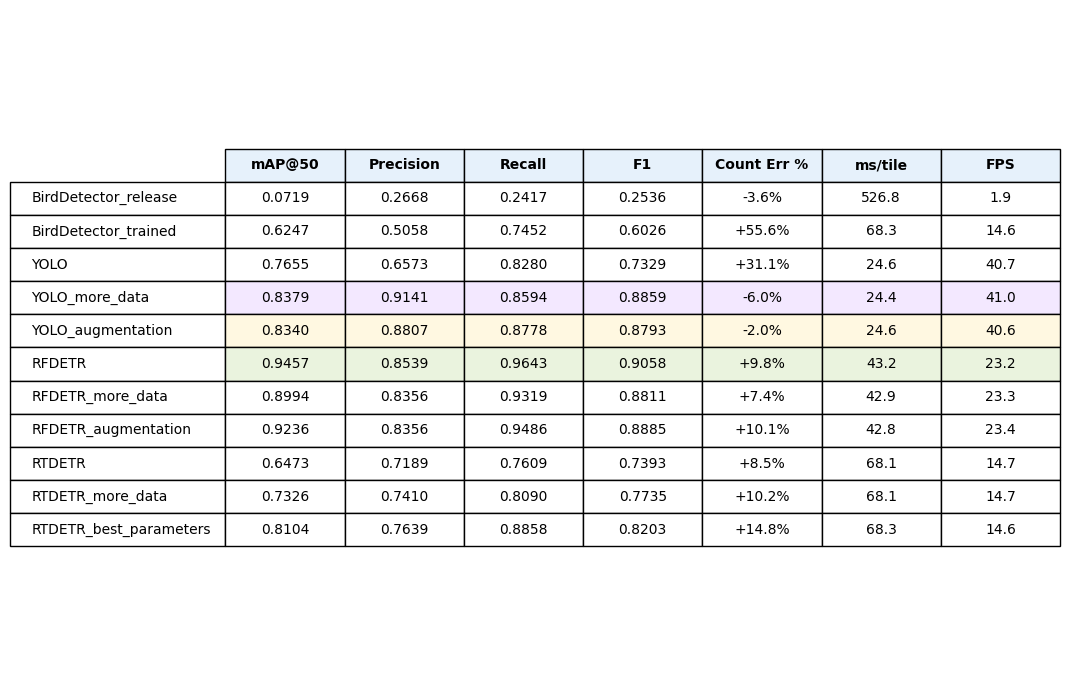

,mAP@50,Precision,Recall,F1,Count Err %,ms/tile,FPS
Model,,,,,,,
BirdDetector_release,0.0719,0.2668,0.2417,0.2536,-3.6%,526.8,1.9
BirdDetector_trained,0.6247,0.5058,0.7452,0.6026,+55.6%,68.3,14.6
YOLO,0.7655,0.6573,0.8280,0.7329,+31.1%,24.6,40.7
YOLO_more_data,0.8379,0.9141,0.8594,0.8859,-6.0%,24.4,41.0
YOLO_augmentation,0.8340,0.8807,0.8778,0.8793,-2.0%,24.6,40.6
RFDETR,0.9457,0.8539,0.9643,0.9058,+9.8%,43.2,23.2
RFDETR_more_data,0.8994,0.8356,0.9319,0.8811,+7.4%,42.9,23.3
RFDETR_augmentation,0.9236,0.8356,0.9486,0.8885,+10.1%,42.8,23.4
RTDETR,0.6473,0.7189,0.7609,0.7393,+8.5%,68.1,14.7


In [7]:
plot_comparison_table(results)

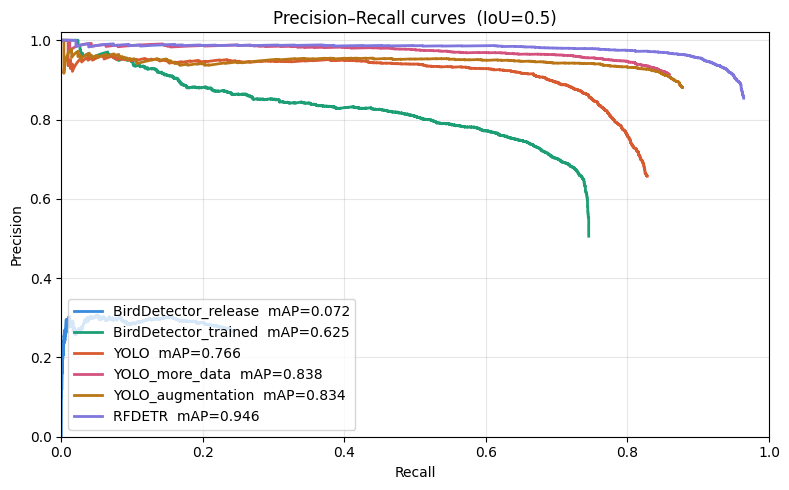

In [8]:
plot_pr_curves(results)

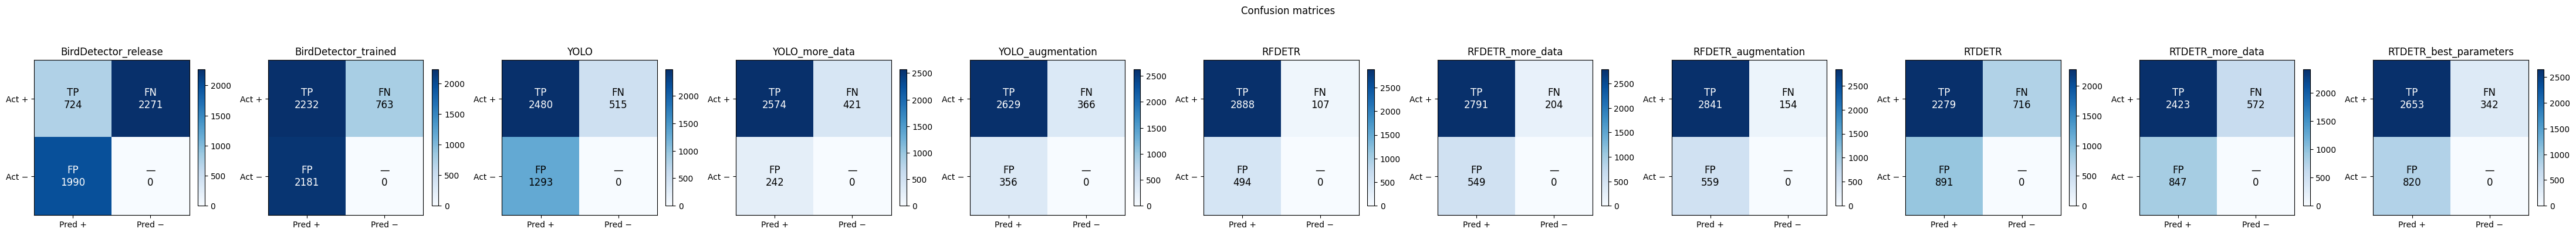

In [9]:
plot_all_confusion_matrices(results)